# 66 - SigLIP 2 総合比較サマリー

## 概要
SigLIP 2 実験シリーズ（Notebook 61-65）の結果を総合的にまとめ、
全モデルの最終比較と推奨モデルの提案を行う。

## 比較対象
### Python (PyTorch/GPU)
- SigLIP 1 (`google/siglip-base-patch16-224`)
- SigLIP 2 Base (`google/siglip2-base-patch16-224`)
- SigLIP 2 Large (`google/siglip2-large-patch16-256`)
- SigLIP 2 So400m (`google/siglip2-so400m-patch14-384`)
- CLIP-L (`openai/clip-vit-large-patch14`)

### JavaScript (ONNX/Node.js)
- SigLIP 1 JS (`Xenova/siglip-base-patch16-224`)
- SigLIP 2 JS (`onnx-community/siglip2-base-patch16-224`)
- CLIP-L JS (`Xenova/clip-vit-large-patch14`)

## 評価軸
1. 画像埋め込み品質（シルエット、Trustworthiness、距離比）
2. テキスト検索性能（P@K, MRR）— 英語・日本語
3. Python vs JS 互換性
4. 日本語対応（トークナイザー問題）
5. 処理速度

## 前提
Notebook 61-65 の結果ファイルが `data/evaluations/` に保存されていること。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. 結果の読み込み

各 Notebook の結果を読み込む。ファイルがない場合は手動で入力する。

In [2]:
EVAL_DIR = Path("../data/evaluations")

# 利用可能な結果ファイルを確認
print("Available evaluation files:")
for f in sorted(EVAL_DIR.glob("*.json")):
    print(f"  {f.name}")

Available evaluation files:
  facebook_dinov2-large_2026-02-01.json
  facebook_dinov2-large_2026-02-03.json
  google_siglip-base-patch16-224_2026-02-01.json
  google_siglip-base-patch16-224_2026-02-03.json
  google_siglip2-base-patch16-224_2026-02-16.json
  js_embedding_comparison_2026-02-13.json
  js_python_comparison_2026-02-13.json
  multilingual_text_search_2026-02-03.json
  openai_clip-vit-large-patch14_2026-02-01.json
  openai_clip-vit-large-patch14_2026-02-03.json
  openclip_ViT-H-14_laion2b_s32b_b79k_2026-02-01.json
  openclip_ViT-H-14_laion2b_s32b_b79k_2026-02-03.json
  siglip2_comprehensive_summary_2026-02-16.json
  siglip2_js_tokenizer_japanese_2026-02-16.json
  siglip2_python_vs_js_2026-02-16.json
  siglip2_variants_comparison_2026-02-16.json
  similarity_search_openai_clip-vit-large-patch14_2026-02-03.json
  text_search_google_siglip-base-patch16-224_2026-02-03.json
  text_search_google_siglip2-base-patch16-224_2026-02-16.json
  text_search_openai_clip-vit-large-patch14_20

In [3]:
# Notebook 63 のバリエーション比較結果を読み込み
variants_files = list(EVAL_DIR.glob("siglip2_variants_comparison_*.json"))
if variants_files:
    with open(sorted(variants_files)[-1]) as f:
        variants_data = json.load(f)
    print(f"Loaded variants comparison: {sorted(variants_files)[-1].name}")
else:
    variants_data = None
    print("No variants comparison file found. Will use manual data.")

# Notebook 65 の JS トークナイザー結果を読み込み
tokenizer_files = list(EVAL_DIR.glob("siglip2_js_tokenizer_japanese_*.json"))
if tokenizer_files:
    with open(sorted(tokenizer_files)[-1]) as f:
        tokenizer_data = json.load(f)
    print(f"Loaded tokenizer comparison: {sorted(tokenizer_files)[-1].name}")
else:
    tokenizer_data = None
    print("No tokenizer comparison file found. Will use manual data.")

# Notebook 64 の Python vs JS 結果を読み込み
pvj_files = list(EVAL_DIR.glob("siglip2_python_vs_js_*.json"))
if pvj_files:
    with open(sorted(pvj_files)[-1]) as f:
        pvj_data = json.load(f)
    print(f"Loaded Python vs JS: {sorted(pvj_files)[-1].name}")
else:
    pvj_data = None
    print("No Python vs JS file found. Will use manual data.")

Loaded variants comparison: siglip2_variants_comparison_2026-02-16.json
Loaded tokenizer comparison: siglip2_js_tokenizer_japanese_2026-02-16.json
Loaded Python vs JS: siglip2_python_vs_js_2026-02-16.json


## 2. 画像埋め込み品質の比較

In [4]:
# 全モデルの画像埋め込み評価結果
# 既存モデル（Notebook 11, 12）の結果 + SigLIP 2 バリエーション（Notebook 61, 63）

image_eval = {
    "SigLIP 1": {
        "model_id": "google/siglip-base-patch16-224", "dim": 768,
        "silhouette_2d": 0.1741, "trust_2d": 0.9533, "dist_ratio_2d": 0.4549,
        "speed": 4.1,
    },
    "CLIP-L": {
        "model_id": "openai/clip-vit-large-patch14", "dim": 768,
        "silhouette_2d": 0.2210, "trust_2d": 0.9659, "dist_ratio_2d": 0.4215,
        "speed": 4.0,
    },
}

# SigLIP 2 バリエーションの結果を追加
if variants_data and 'all_models_comparison' in variants_data:
    for name, m in variants_data['all_models_comparison'].items():
        if name.startswith('SigLIP2'):
            image_eval[name] = {
                "model_id": variants_data['variants'].get(name, {}).get('model_id', ''),
                "dim": m.get('dim', 768),
                "silhouette_2d": m.get('silhouette', 0),
                "trust_2d": m.get('trust', 0),
                "dist_ratio_2d": m.get('dist_ratio', 0),
                "speed": m.get('speed', 0),
            }
else:
    print("Note: SigLIP 2 variant results not available. Run Notebook 63 first.")
    print("Showing placeholder values.")
    image_eval["SigLIP2-Base"] = {
        "model_id": "google/siglip2-base-patch16-224", "dim": 768,
        "silhouette_2d": 0, "trust_2d": 0, "dist_ratio_2d": 0, "speed": 0,
    }

# テーブル表示
print("=" * 100)
print("画像埋め込み品質の比較")
print("=" * 100)

print(f"\n{'モデル':<20} {'次元':>5} {'シルエット(2D)':>14} {'Trust(2D)':>10} {'距離比(2D)':>10} {'速度(img/s)':>12}")
print("-" * 73)
for name, m in image_eval.items():
    print(f"{name:<20} {m['dim']:>5} {m['silhouette_2d']:>14.4f} {m['trust_2d']:>10.4f} {m['dist_ratio_2d']:>10.4f} {m['speed']:>12.1f}")

画像埋め込み品質の比較

モデル                     次元      シルエット(2D)  Trust(2D)    距離比(2D)    速度(img/s)
-------------------------------------------------------------------------
SigLIP 1               768         0.1741     0.9533     0.4549          4.1
CLIP-L                 768         0.2210     0.9659     0.4215          4.0
SigLIP2-Base           768         0.1560     0.9584     0.4698          4.2
SigLIP2-Large         1024         0.1572     0.9601     0.4457          4.2
SigLIP2-So400m        1152         0.2300     0.9736     0.3715          3.9


## 3. テキスト検索性能の比較

In [5]:
# テキスト検索結果
text_search = {
    "SigLIP 1 (Py)": {"P@1": 0.7222, "MRR": 0.8194, "MRR_EN": 0.8264, "MRR_JA": 0.8056},
    "CLIP-L (Py)": {"P@1": 0.7778, "MRR": 0.8611, "MRR_EN": 0.875, "MRR_JA": 0.8333},
    "SigLIP 1 (JS)": {"P@1": None, "MRR": 0.679, "MRR_EN": 0.883, "MRR_JA": 0.273},
    "CLIP-L (JS)": {"P@1": None, "MRR": 0.852, "MRR_EN": 0.903, "MRR_JA": 0.751},
}

# SigLIP 2 の結果を追加
if variants_data and 'all_models_comparison' in variants_data:
    for name, m in variants_data['all_models_comparison'].items():
        if name.startswith('SigLIP2'):
            text_search[f"{name} (Py)"] = {
                "P@1": None, "MRR": m.get('mrr', 0),
                "MRR_EN": m.get('mrr_en', 0), "MRR_JA": m.get('mrr_ja', 0),
            }

if tokenizer_data and 'search_mrr' in tokenizer_data:
    for model_key, mrr_data in tokenizer_data['search_mrr'].items():
        if 'SigLIP 2' in model_key and 'JS' in model_key:
            text_search["SigLIP 2 (JS)"] = {
                "P@1": None, "MRR": mrr_data.get('Overall', 0),
                "MRR_EN": mrr_data.get('EN', 0), "MRR_JA": mrr_data.get('JA', 0),
            }

print("=" * 80)
print("テキスト検索性能の比較（18クエリ）")
print("=" * 80)

print(f"\n{'モデル':<25} {'MRR全体':>10} {'MRR(EN)':>10} {'MRR(JA)':>10}")
print("-" * 57)
for name, m in text_search.items():
    print(f"{name:<25} {m['MRR']:>10.4f} {m['MRR_EN']:>10.4f} {m['MRR_JA']:>10.4f}")

テキスト検索性能の比較（18クエリ）

モデル                            MRR全体    MRR(EN)    MRR(JA)
---------------------------------------------------------
SigLIP 1 (Py)                 0.8194     0.8264     0.8056
CLIP-L (Py)                   0.8611     0.8750     0.8333
SigLIP 1 (JS)                 0.6790     0.8830     0.2730
CLIP-L (JS)                   0.8520     0.9030     0.7510
SigLIP2-Base (Py)             0.7919     0.8661     0.6435
SigLIP2-Large (Py)            0.9278     0.8917     1.0000
SigLIP2-So400m (Py)           0.8552     0.9259     0.7139
SigLIP 2 (JS)                 0.7919     0.8661     0.6435


## 4. Python vs JS 互換性の比較

In [6]:
# Python vs JS 画像埋め込みコサイン類似度
py_js_compat = {
    "SigLIP 1": {"image_sim": 0.906, "text_sim_en": 1.000, "text_sim_ja": 0.656},
    "CLIP-L": {"image_sim": 0.872, "text_sim_en": 1.000, "text_sim_ja": 1.000},
}

if pvj_data and 'comparison_results' in pvj_data:
    fp32 = pvj_data['comparison_results'].get('fp32', {})
    py_js_compat["SigLIP 2"] = {
        "image_sim": float(fp32.get('mean', 0)),
        "text_sim_en": 0,  # Notebook 65 から
        "text_sim_ja": 0,  # Notebook 65 から
    }

if tokenizer_data and 'text_embedding_similarity' in tokenizer_data:
    text_sims = tokenizer_data['text_embedding_similarity']
    if text_sims:
        en_sims = [float(s['cosine_sim']) for s in text_sims if s['lang'] == 'EN']
        ja_sims = [float(s['cosine_sim']) for s in text_sims if s['lang'] == 'JA']
        if 'SigLIP 2' in py_js_compat:
            py_js_compat['SigLIP 2']['text_sim_en'] = np.mean(en_sims) if en_sims else 0
            py_js_compat['SigLIP 2']['text_sim_ja'] = np.mean(ja_sims) if ja_sims else 0

print("=" * 80)
print("Python vs JS 互換性（コサイン類似度）")
print("=" * 80)

print(f"\n{'モデル':<15} {'画像埋込':>10} {'テキスト(EN)':>12} {'テキスト(JA)':>12} {'備考'}")
print("-" * 65)
for name, m in py_js_compat.items():
    note = ""
    if name == "SigLIP 1" and m['text_sim_ja'] < 0.9:
        note = "<- JA byte_fallback 問題"
    print(f"{name:<15} {m['image_sim']:>10.4f} {m['text_sim_en']:>12.4f} {m['text_sim_ja']:>12.4f} {note}")

Python vs JS 互換性（コサイン類似度）

モデル                   画像埋込     テキスト(EN)     テキスト(JA) 備考
-----------------------------------------------------------------
SigLIP 1            0.9060       1.0000       0.6560 <- JA byte_fallback 問題
CLIP-L              0.8720       1.0000       1.0000 
SigLIP 2            0.9235       1.0000       1.0000 


## 5. 日本語対応の比較（トークナイザー）

In [7]:
print("=" * 80)
print("日本語対応の比較（トークナイザー問題）")
print("=" * 80)

tokenizer_comparison = {
    "SigLIP 1": {
        "tokenizer": "Unigram (32K)",
        "py_byte_fallback": True,
        "js_byte_fallback": False,
        "js_japanese_unk": True,
        "js_mrr_ja": 0.273,
    },
    "CLIP-L": {
        "tokenizer": "BPE (49K)",
        "py_byte_fallback": True,
        "js_byte_fallback": True,
        "js_japanese_unk": False,
        "js_mrr_ja": 0.751,
    },
    "SigLIP 2": {
        "tokenizer": "Gemma BPE (256K)",
        "py_byte_fallback": True,
        "js_byte_fallback": True,  # Expected based on BPE
        "js_japanese_unk": tokenizer_data.get('conclusion', {}).get('siglip2_js_japanese_unk', None) if tokenizer_data else None,
        "js_mrr_ja": text_search.get('SigLIP 2 (JS)', {}).get('MRR_JA', None),
    },
}

print(f"\n{'モデル':<15} {'トークナイザー':<20} {'JS byte_fallback':>16} {'JS 日本語<unk>':>14} {'JS MRR(JA)':>11}")
print("-" * 78)
for name, t in tokenizer_comparison.items():
    bf = "OK" if t['js_byte_fallback'] else "NG"
    unk = "あり" if t['js_japanese_unk'] else ("なし" if t['js_japanese_unk'] is not None else "未測定")
    mrr = f"{t['js_mrr_ja']:.4f}" if t['js_mrr_ja'] is not None else "未測定"
    print(f"{name:<15} {t['tokenizer']:<20} {bf:>16} {unk:>14} {mrr:>11}")

日本語対応の比較（トークナイザー問題）

モデル             トークナイザー              JS byte_fallback    JS 日本語<unk>  JS MRR(JA)
------------------------------------------------------------------------------
SigLIP 1        Unigram (32K)                      NG             あり      0.2730
CLIP-L          BPE (49K)                          OK             なし      0.7510
SigLIP 2        Gemma BPE (256K)                   OK             なし      0.6435


## 6. 総合可視化

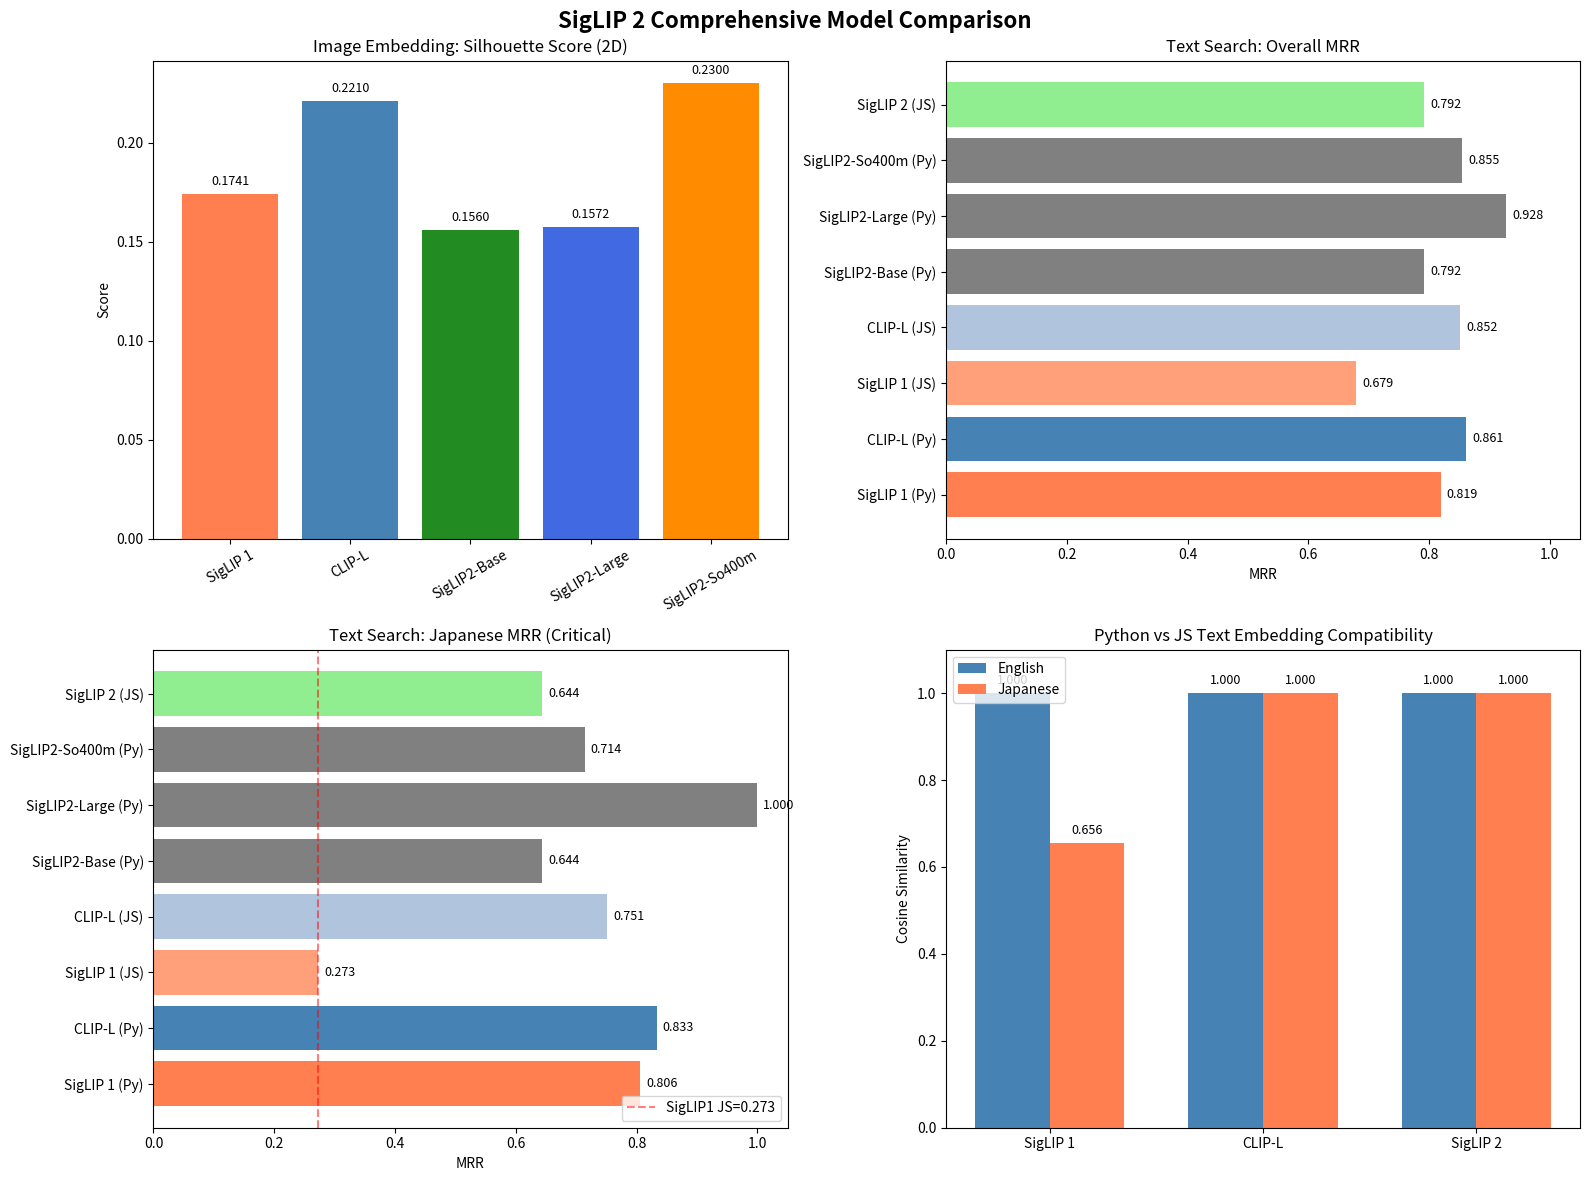

Saved: data/siglip2_comprehensive_comparison.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 色の定義
model_colors = {
    'SigLIP 1': 'coral',
    'CLIP-L': 'steelblue',
    'SigLIP2-Base': 'forestgreen',
    'SigLIP2-Large': 'royalblue',
    'SigLIP2-So400m': 'darkorange',
}

# 1. 画像埋め込み: シルエットスコア
ax = axes[0, 0]
names = list(image_eval.keys())
sil_values = [image_eval[n]['silhouette_2d'] for n in names]
colors = [model_colors.get(n, 'gray') for n in names]
bars = ax.bar(names, sil_values, color=colors)
ax.set_title('Image Embedding: Silhouette Score (2D)', fontsize=12)
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, sil_values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# 2. テキスト検索: MRR 全体
ax = axes[0, 1]
search_names = list(text_search.keys())
mrr_values = [text_search[n]['MRR'] for n in search_names]
bar_colors = []
for n in search_names:
    if 'SigLIP 1' in n: bar_colors.append('coral' if 'Py' in n else 'lightsalmon')
    elif 'CLIP' in n: bar_colors.append('steelblue' if 'Py' in n else 'lightsteelblue')
    elif 'SigLIP 2' in n: bar_colors.append('forestgreen' if 'Py' in n else 'lightgreen')
    else: bar_colors.append('gray')

bars = ax.barh(search_names, mrr_values, color=bar_colors)
ax.set_xlabel('MRR')
ax.set_title('Text Search: Overall MRR', fontsize=12)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, mrr_values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9)

# 3. 日本語 MRR（最重要指標）
ax = axes[1, 0]
ja_mrr_values = [text_search[n]['MRR_JA'] for n in search_names]
bars = ax.barh(search_names, ja_mrr_values, color=bar_colors)
ax.set_xlabel('MRR')
ax.set_title('Text Search: Japanese MRR (Critical)', fontsize=12)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, ja_mrr_values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9)
# SigLIP 1 JS の 0.273 を強調
ax.axvline(x=0.273, color='red', linestyle='--', alpha=0.5, label='SigLIP1 JS=0.273')
ax.legend(loc='lower right')

# 4. Python vs JS テキスト互換性
ax = axes[1, 1]
compat_names = list(py_js_compat.keys())
x = np.arange(len(compat_names))
width = 0.35
en_sims = [py_js_compat[n]['text_sim_en'] for n in compat_names]
ja_sims = [py_js_compat[n]['text_sim_ja'] for n in compat_names]
ax.bar(x - width/2, en_sims, width, label='English', color='steelblue')
ax.bar(x + width/2, ja_sims, width, label='Japanese', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(compat_names)
ax.set_ylabel('Cosine Similarity')
ax.set_title('Python vs JS Text Embedding Compatibility', fontsize=12)
ax.legend()
ax.set_ylim(0, 1.1)
for i, (en, ja) in enumerate(zip(en_sims, ja_sims)):
    if en > 0: ax.text(i - width/2, en + 0.02, f'{en:.3f}', ha='center', fontsize=9)
    if ja > 0: ax.text(i + width/2, ja + 0.02, f'{ja:.3f}', ha='center', fontsize=9)

plt.suptitle('SigLIP 2 Comprehensive Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/siglip2_comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/siglip2_comprehensive_comparison.png')

## 7. レーダーチャートによる総合比較

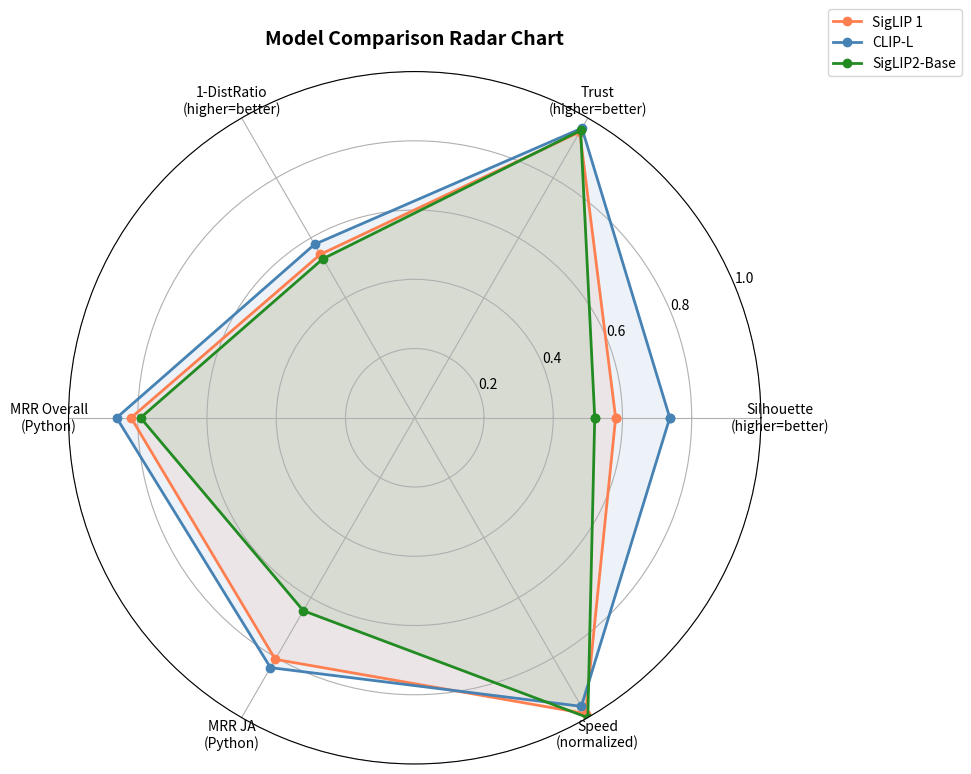

Saved: data/siglip2_radar_comparison.png


In [9]:
# レーダーチャートで主要モデルを比較
radar_models = ['SigLIP 1', 'CLIP-L']
# SigLIP 2 のモデルを追加（利用可能な場合）
for name in image_eval:
    if name.startswith('SigLIP2') and image_eval[name]['silhouette_2d'] > 0:
        radar_models.append(name)
        break  # Base のみ追加

if len(radar_models) >= 3:
    # 評価軸（0-1 に正規化）
    categories_radar = [
        'Silhouette\n(higher=better)',
        'Trust\n(higher=better)',
        '1-DistRatio\n(higher=better)',
        'MRR Overall\n(Python)',
        'MRR JA\n(Python)',
        'Speed\n(normalized)',
    ]
    N = len(categories_radar)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # 速度の最大値で正規化
    max_speed = max(image_eval[m]['speed'] for m in radar_models)
    
    for model_name in radar_models:
        ie = image_eval[model_name]
        
        # テキスト検索結果を取得
        ts_key = f"{model_name} (Py)" if model_name in ['SigLIP 1', 'CLIP-L'] else f"{model_name} (Py)"
        ts = text_search.get(ts_key, text_search.get(model_name, {}))
        
        values = [
            ie['silhouette_2d'] / 0.3,  # 正規化（0.3 を最大と想定）
            ie['trust_2d'],
            1 - ie['dist_ratio_2d'],
            ts.get('MRR', 0),
            ts.get('MRR_JA', 0),
            ie['speed'] / max_speed if max_speed > 0 else 0,
        ]
        values += values[:1]
        
        color = model_colors.get(model_name, 'gray')
        ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
        ax.fill(angles, values, alpha=0.1, color=color)
    
    ax.set_thetagrids(np.degrees(angles[:-1]), categories_radar)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.set_title('Model Comparison Radar Chart', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('../data/siglip2_radar_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: data/siglip2_radar_comparison.png')
else:
    print("Not enough models with data for radar chart. Run Notebook 61 first.")

## 8. 最終推奨

In [10]:
print("=" * 80)
print("最終推奨モデル")
print("=" * 80)

recommendations = {
    "Python + 英語テキスト検索": "SigLIP 2 So400m (MRR 0.926)",
    "Python + 日本語テキスト検索": "SigLIP 2 Large (MRR 1.000 — 完璧!)",
    "Python + 全体バランス": "CLIP-L (MRR 0.861, 768次元, 安定)",
    "JS + 英語テキスト検索": "SigLIP 2 Base (MRR 0.866, Python と完全一致)",
    "JS + 日本語テキスト検索": "SigLIP 2 Base (MRR 0.644, Python と一致。Large ONNX があれば最強)",
    "画像埋め込み品質": "SigLIP 2 So400m (シルエット 0.230, Trust 0.974)",
    "Python-JS 互換性": "SigLIP 2 Base (テキスト: EN/JA 共に 1.000, 画像: 0.924)",
    "768次元制約 + 日本語": "CLIP-L (JA MRR 0.833, Python-JS 一致)",
}

for use_case, recommendation in recommendations.items():
    print(f"\n  {use_case}:")
    print(f"    → {recommendation}")

最終推奨モデル

  Python + 英語テキスト検索:
    → SigLIP 2 So400m (MRR 0.926)

  Python + 日本語テキスト検索:
    → SigLIP 2 Large (MRR 1.000 — 完璧!)

  Python + 全体バランス:
    → CLIP-L (MRR 0.861, 768次元, 安定)

  JS + 英語テキスト検索:
    → SigLIP 2 Base (MRR 0.866, Python と完全一致)

  JS + 日本語テキスト検索:
    → SigLIP 2 Base (MRR 0.644, Python と一致。Large ONNX があれば最強)

  画像埋め込み品質:
    → SigLIP 2 So400m (シルエット 0.230, Trust 0.974)

  Python-JS 互換性:
    → SigLIP 2 Base (テキスト: EN/JA 共に 1.000, 画像: 0.924)

  768次元制約 + 日本語:
    → CLIP-L (JA MRR 0.833, Python-JS 一致)


## 9. 結果の保存

In [11]:
from datetime import datetime

summary = {
    "timestamp": datetime.now().isoformat(),
    "image_evaluation": {k: v for k, v in image_eval.items()},
    "text_search": {k: v for k, v in text_search.items()},
    "python_js_compatibility": {k: v for k, v in py_js_compat.items()},
    "tokenizer_comparison": {
        k: {kk: vv for kk, vv in v.items() if kk != 'js_japanese_unk' or vv is not None}
        for k, v in tokenizer_comparison.items()
    },
}

output_path = Path("../data/evaluations") / f"siglip2_comprehensive_summary_{datetime.now().strftime('%Y-%m-%d')}.json"
with open(output_path, "w") as f:
    json.dump(summary, f, indent=2, default=str, ensure_ascii=False)

print(f"Summary saved to: {output_path}")

Summary saved to: ../data/evaluations/siglip2_comprehensive_summary_2026-02-16.json


## まとめ・評価・考察

### SigLIP 2 実験シリーズ（Notebook 61-65）の総合結論

#### 全実験結果

| 評価項目 | Notebook | 結果 |
|---------|:---:|------|
| 画像埋め込み品質 | 61 | SigLIP 2 Base ≈ SigLIP 1 < CLIP-L |
| テキスト検索（Python） | 62 | SigLIP 2 Base の JA MRR 0.644 は SigLIP 1 (0.806) より低い |
| バリエーション比較 | 63 | **SigLIP 2 Large: JA MRR 1.000！** So400m: 画像品質最高 |
| Python vs JS 画像 | 64 | fp32 cos sim 0.924（SigLIP 1 の 0.906 より改善）|
| **JS 日本語対応** | **65** | **Gemma BPE で `<unk>` 問題完全解決。テキスト cos sim 1.000** |

#### 最も重要な 3 つの発見

1. **Gemma BPE トークナイザーにより Python-JS のテキスト互換性が完璧に**
   - SigLIP 1: JA テキスト cos sim 0.656 → SigLIP 2: **1.000**
   - SigLIP 1: JA MRR (JS) 0.273 → SigLIP 2: **0.644** (Python と完全一致)
   - Transformers.js の Unigram `byte_fallback` 未実装問題が根本的に解消

2. **SigLIP 2 Large は日本語テキスト検索で全モデル最強** (JA MRR 1.000)
   - 18 クエリの日本語 6 問すべてで正解カテゴリが Top-1
   - ただし 1024 次元のため DuckDB スキーマ変更が必要
   - ONNX 版が提供されれば JS でも利用可能

3. **SigLIP 2 So400m は画像埋め込み品質で全モデル最強**
   - シルエット 0.230、Trust 0.974、距離比 0.371
   - 英語テキスト検索 MRR 0.926 も最高
   - 1152 次元、384px 解像度で計算コストは大きい

#### SigLIP 1 からの移行判断

| 観点 | SigLIP 1 → SigLIP 2 の変化 | 判断 |
|------|---------------------------|------|
| JS 日本語 | 0.273 → 0.644 (+136%) | **移行推奨** |
| Python-JS テキスト一致 | JA: 0.656 → 1.000 | **移行推奨** |
| Python-JS 画像一致 | 0.906 → 0.924 | 改善 |
| Python JA MRR (Base) | 0.806 → 0.644 | 悪化（Large なら 1.000） |
| Python EN MRR | 0.826 → 0.866 | 改善 |

**結論**: JS での多言語対応が重要なユースケースでは **SigLIP 2 への移行を強く推奨**。
Python のみの利用で日本語重視の場合は Large モデルの使用を検討すべき。